# Path Finder: What are the potential paths between two nodes?

This pipeline can be used to get a set of paths between nodes A and B, and rank the paths by various criteria.

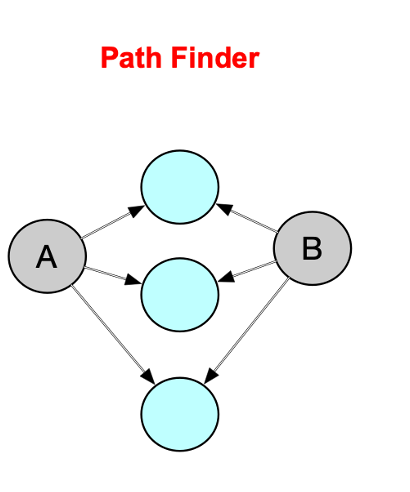


In [1]:

from TCT import name_resolver
from TCT import translator_metakg
from TCT import translator_kpinfo
from TCT import translator_query

from TCT import TCT



import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import requests
import json
import pandas as pd
import  seaborn as sns
import networkx as nx
import numpy as np
import ipycytoscape
import yaml


In [2]:
APInames, metaKG, Translator_KP_info = translator_metakg.load_translator_resources()

All_predicates = list(set(metaKG['Predicate']))
All_categories = list((set(list(set(metaKG['Subject']))+list(set(metaKG['Object'])))))
API_withMetaKG = list(set(metaKG['API']))

    # generate a dictionary of API and its predicates
API_predicates = {}
for api in API_withMetaKG:
    API_predicates[api] = list(set(metaKG[metaKG['API'] == api]['Predicate']))

In [3]:
# select a list of APIs to use and a list of predicates to use
selected_APIlist = []

if len(selected_APIlist) == 0:
    select_APIs = APInames
else:
    select_APIs = {k: APInames[k] for k in selected_APIlist if k in APInames}

selected_metaKG = metaKG[metaKG['API'].isin(select_APIs.keys())]
#print(select_APIs)
print(selected_metaKG.shape)


(22116, 5)


In [11]:
print(len(select_APIs))

54


In [4]:
name_resolver.lookup('miR-155')

TranslatorNode(curie='NCBIGene:100033679', label='mir155', types=['biolink:Gene', 'biolink:GeneOrGeneProduct', 'biolink:GenomicEntity', 'biolink:ChemicalEntityOrGeneOrGeneProduct', 'biolink:PhysicalEssence', 'biolink:OntologyClass', 'biolink:BiologicalEntity', 'biolink:ThingWithTaxon', 'biolink:NamedThing', 'biolink:Entity', 'biolink:PhysicalEssenceOrOccurrent', 'biolink:MacromolecularMachineMixin'], synonyms=None, curie_synonyms=None, attributes=None)

NCBIGene:396991
MONDO:0100096
Automat-pharos(Trapi v1.5.0): Success!
CATRAX Pharmacogenomics KP - TRAPI 1.5.0: Success!
Automat-robokop(Trapi v1.5.0): Success!
Microbiome KP - TRAPI 1.5.0: Success!
RTX KG2 - TRAPI 1.5.0: Success!
Service Provider TRAPI: Success!
BioThings Explorer (BTE) TRAPI: Success!
NCBIGene:1055: no preferred name
NCBIGene:28755: no preferred name
NCBIGene:3497: no preferred name
NodeNorm does not know about these identifiers: CHEMBL.TARGET:CHEMBL1697664,CHEMBL.TARGET:CHEMBL6188,CHEMBL.TARGET:CHEMBL4295579,CHEMBL.TARGET:CHEMBL1075031,CHEMBL.TARGET:CHEMBL4295609,CHEMBL.TARGET:CHEMBL1287621,CHEMBL.TARGET:CHEMBL3499,CHEMBL.TARGET:CHEMBL4295625,CHEMBL.TARGET:CHEMBL4295542,CHEMBL.TARGET:CHEMBL1741198,CHEMBL.TARGET:CHEMBL3309030,CHEMBL.TARGET:CHEMBL4882,CHEMBL.TARGET:CHEMBL3309037,WB:WBGene00002976,WB:WBGene00000039,WB:WBGene00005643,WB:WBGene00005647,WB:WBGene00005648,WB:WBGene00005649,WB:WBGene00012084,WB:WBGene00013969,WB:WBGene00009278,ZFIN:ZDB-GENE-081104-23,RGD:649

/home/yzhang/Translator_component_toolkit/TCT/TCT.py:1632: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=fontsize)


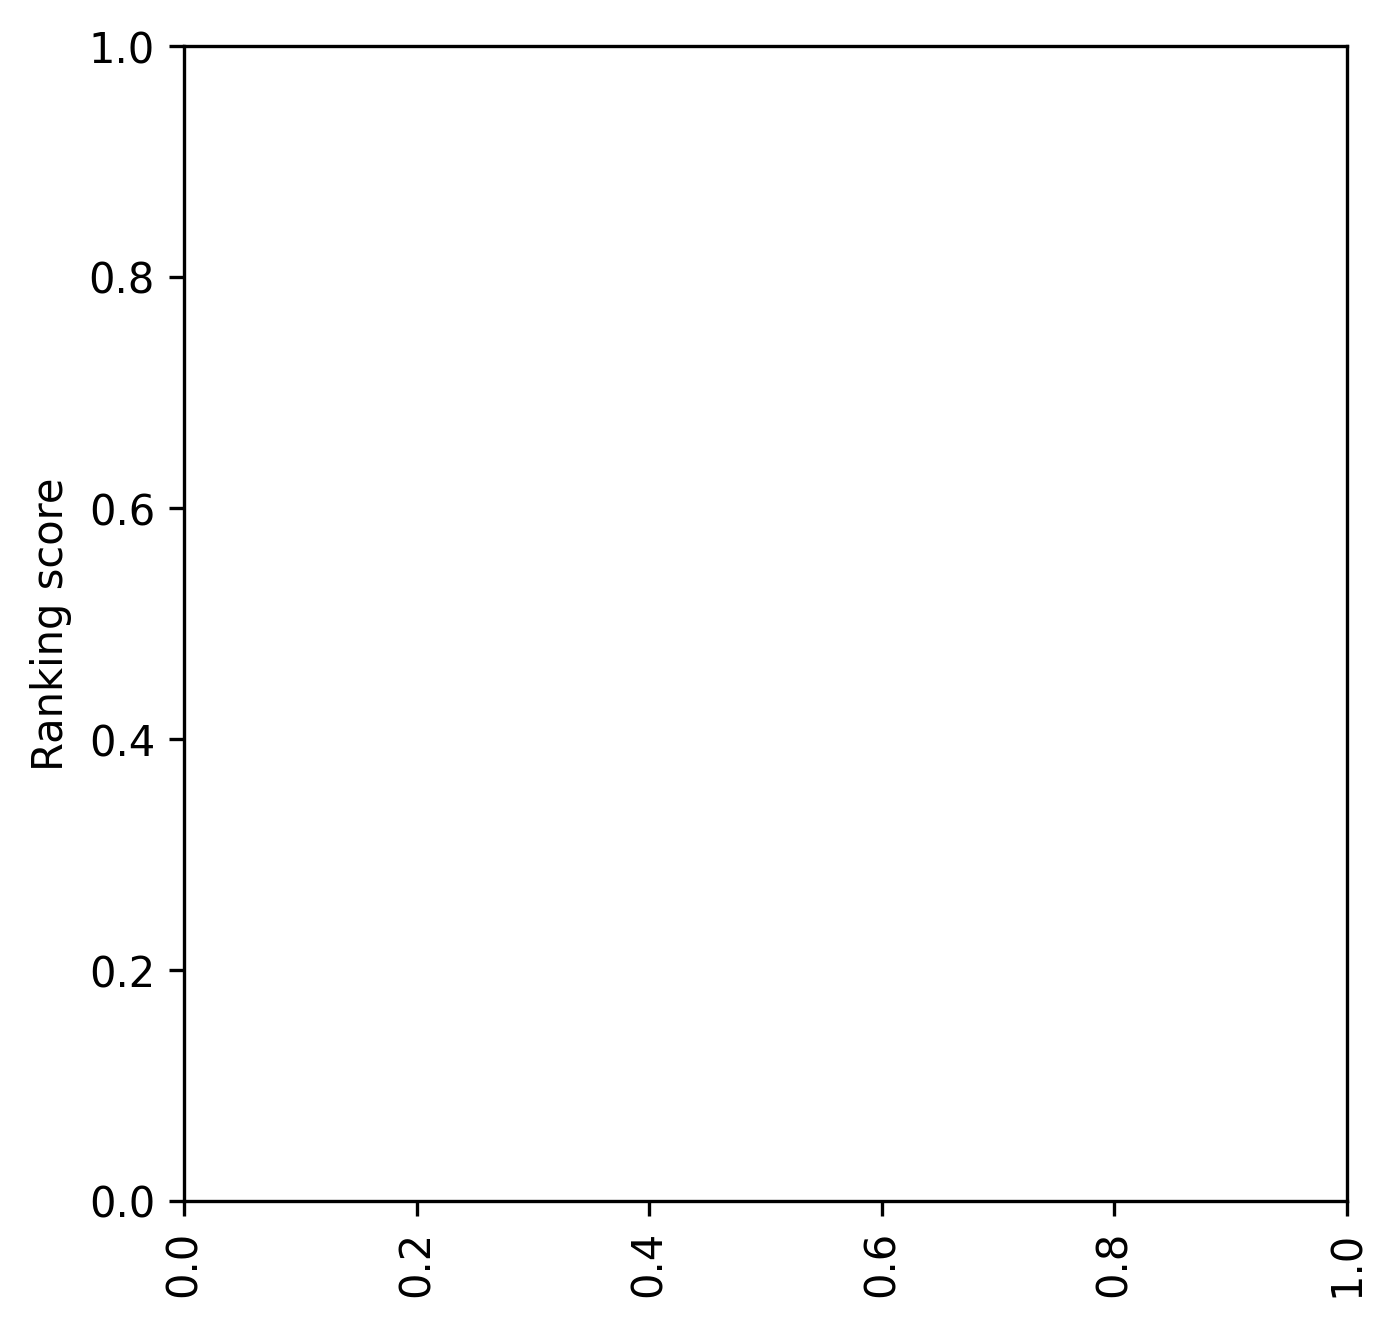

In [12]:
paths, input_node1_id, input_node2_id, result1, result2, result_parsed1, result_parsed2, result_ranked_by_primary_infores1, result_ranked_by_primary_infores2 = TCT.Path_finder(input_node1='IFNG', 
                                                                                                                                                                                input_node2= 'COVID-19', 
                                                                                                                                                                                intermediate_categories=['biolink:Protein', 'biolink:Gene' ], 
                                                                                                                                                                                APInames=select_APIs, 
                                                                                                                                                                                metaKG=selected_metaKG, 
                                                                                                                                                                                API_predicates=API_predicates)

In [6]:
intermediate_node = name_resolver.lookup('IDO2').curie



In [7]:
matches2 = []
for k in result2.keys():
    if input_node2_id == result2[k]['subject'] and intermediate_node == result2[k]['object']:
        matches2.append(result2[k])
    elif input_node2_id == result2[k]['object'] and intermediate_node == result2[k]['subject']:
        matches2.append(result2[k])

for k in matches2:
    print(k['sources'])

In [8]:
matches = []
for k in result1.keys():
    if input_node1_id == result1[k]['subject'] and intermediate_node == result1[k]['object']:
        matches.append(result1[k])
    elif input_node1_id == result1[k]['object'] and intermediate_node == result1[k]['subject']:
        matches.append(result1[k])

for k in matches:
    print(k['sources'])

In [9]:


# Create a DataFrame from the matches
df = pd.DataFrame(matches)

# Display the DataFrame
df

""


In [10]:
import lmstudio as lms
model = lms.llm("openai/gpt-oss-120b")
input_text = str(result1) + 'and '+str(result2)
question = "summarize the path that go over NCBIGene:23411 between NCBIGene:2739 and CHEBI:45713" 

ModuleNotFoundError: No module named 'lmstudio'

In [ ]:
result = model.respond("find the path between NPC1 and WNT7B" )

In [ ]:
result

In [ ]:
paths

In [ ]:
paths

In [ ]:
'NFE2L2' in paths['output_node_name']

In [ ]:
forplot = TCT.visualize_path(input_node1_id, name_resolver.lookup('HOXB7').curie, input_node2_id, result1, result2) 

In [ ]:
paths, input_node1_id, input_node2_id, result1, result2, result_parsed1, result_parsed2, result_ranked_by_primary_infores1, result_ranked_by_primary_infores2 = TCT.Path_finder('Olaparib', 
                                                                                                                                                                                'BRCA1', 
                                                                                                                                                                                ['biolink:Gene', 'biolink:Protein'], 
                                                                                                                                                                                APInames=select_APIs, 
                                                                                                                                                                                metaKG=selected_metaKG, 
                                                                                                                                                                                API_predicates=API_predicates)

In [ ]:
forplot = TCT.visulize_path(input_node1_id, name_resolver.lookup('IDO2').curie, input_node2_id, result1, result2) 

# link to the UI
https://ui.ci.transltr.io/
